Задача бинарной классификации- порекомендует ли пассажир авиакомпанию(yes/no)

Столбцы:

Unnamed: 0 - номер записи (идентификатор)

Airline Name - название авиакомпании

Review Date - дата написания отзыва

Verified - подтвержденный ли отзыв

Содержание отзыва:

Overall_Rating - общая оценка авиакомпании

Review_Title - заголовок отзыва

Review - текст отзыва

Recommended - рекомендует ли пассажир авиакомпанию

Детали перелета:

Aircraft - модель самолета

Type Of Traveller - тип путешественника (бизнес, отдых и т.д.)

Seat Type - класс обслуживания (эконом, бизнес и т.д.)

Route - маршрут перелета

Date Flown - дата перелета

Оценки по категориям:

Seat Comfort - комфорт сидений

Cabin Staff Service - обслуживание бортпроводников

Food & Beverages - еда и напитки

Ground Service - обслуживание на земле

Inflight Entertainment - развлечения на борту

Wifi & Connectivity - Wi-Fi и связь

Value For Money - соотношение цены и качества

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [131]:
url = 'https://drive.google.com/uc?id=1ut284Z8aYM-CIbZj9nZLAZKYPOkP43dr'


output = 'airline_reviews.csv'
gdown.download(url, output, quiet=False)


df = pd.read_csv(output)

print("Размер датасета:", df.shape)
print("\nСтолбцы в датасете:")
print(df.columns.tolist())
print("\nПервые 3 строки:")
df.head(3)

Downloading...
From: https://drive.google.com/uc?id=1ut284Z8aYM-CIbZj9nZLAZKYPOkP43dr
To: /content/airline_reviews.csv
100%|██████████| 20.5M/20.5M [00:00<00:00, 218MB/s]


Размер датасета: (23171, 20)

Столбцы в датасете:
['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title', 'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money', 'Recommended']

Первые 3 строки:


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no


In [132]:
# Посмотрим на информацию о данных
print("Информация о датасете:")
print(df.info())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverage

In [133]:
# Создаем целевую переменную
df['recom'] = df['Recommended'].map({'yes': 1, 'no': 0})

print("Распределение целевой переменной:")
print(df['recom'].value_counts())
print(f"\nДоля рекомендаций: {df['recom'].mean():.1%}")

# Удаляем строки, где нет целевой переменной
df = df.dropna(subset=['recom'])
print(f"Размер после очистки: {df.shape}")

Распределение целевой переменной:
recom
0    15364
1     7807
Name: count, dtype: int64

Доля рекомендаций: 33.7%
Размер после очистки: (23171, 21)


Очень хочется чтобы столбец Overall_Rating был численным, но в нем содержатся оценки от 1 до 9 и символ n, который можно трактовать как отсутствие оценки, поэтому в предобработке удалим этот символ и получим пустые значения в этом столбце

In [134]:
# Числовые признаки - оценки
numeric_columns = [
    'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
    'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity',
    'Value For Money', 'Overall_Rating'
]

# Категориальные признаки - текстовая информация
categorical_columns = [
    'Airline Name', 'Type Of Traveller', 'Seat Type', 'Verified'
]

print("Числовые признаки (оценки):")
for col in numeric_columns:
    print(f"  - {col}")

print("\nКатегориальные признаки:")
for col in categorical_columns:
    print(f"  - {col}")

# Обрабатываем Overall_Rating (удаляем 'n')
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')

# Преобразуем Verified в числовой (но оставим в категориальных)
df['Verified'] = df['Verified'].astype(int)

# Создаем X (признаки) и y (целевая переменная)
X = df[numeric_columns + categorical_columns]
y = df['recom']

print(f"\nИтоговый размер: X {X.shape}, y {y.shape}")

Числовые признаки (оценки):
  - Seat Comfort
  - Cabin Staff Service
  - Food & Beverages
  - Ground Service
  - Inflight Entertainment
  - Wifi & Connectivity
  - Value For Money
  - Overall_Rating

Категориальные признаки:
  - Airline Name
  - Type Of Traveller
  - Seat Type
  - Verified

Итоговый размер: X (23171, 12), y (23171,)


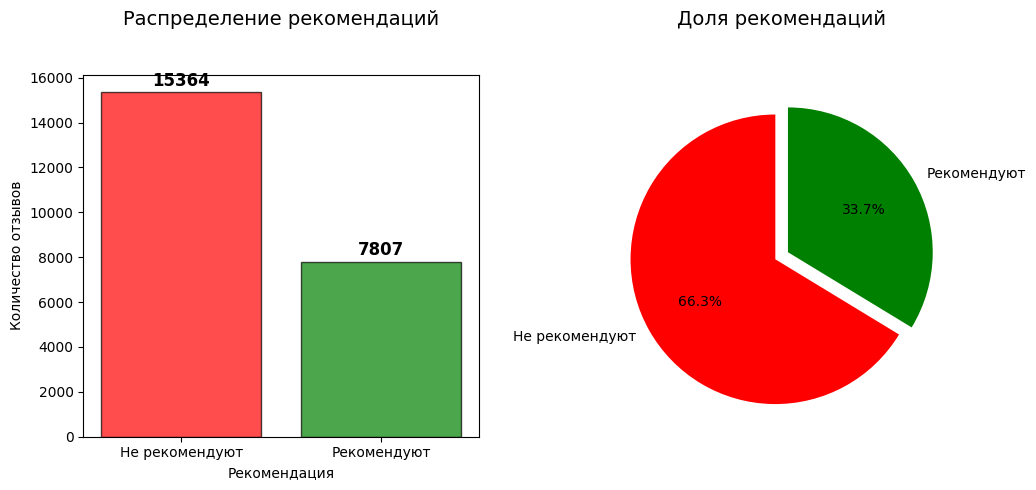

In [135]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
recommend_counts = y.value_counts()
colors = ['red', 'green']
plt.bar(recommend_counts.index, recommend_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Распределение рекомендаций\n', fontsize=14, pad=20)
plt.xlabel('Рекомендация')
plt.ylabel('Количество отзывов')
plt.xticks([0, 1], ['Не рекомендуют', 'Рекомендуют'])
for i, v in enumerate(recommend_counts.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.subplot(1, 3, 2)
plt.pie(recommend_counts.values, labels=['Не рекомендуют', 'Рекомендуют'],
        autopct='%1.1f%%', colors=colors, startangle=90, explode=[0.05, 0.05])
plt.title('Доля рекомендаций\n', fontsize=14, pad=20)

plt.tight_layout()
plt.show()


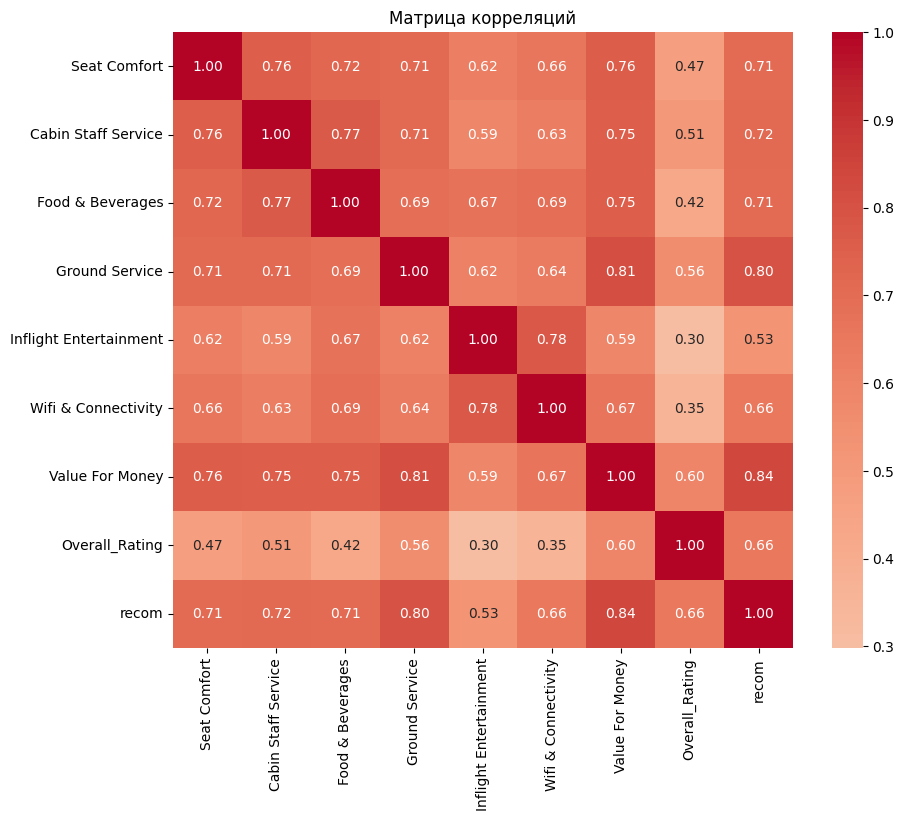

Корреляции с целевой переменной:
  Value For Money     : 0.837
  Ground Service      : 0.801
  Cabin Staff Service : 0.716
  Seat Comfort        : 0.708
  Food & Beverages    : 0.707
  Wifi & Connectivity : 0.656
  Overall_Rating      : 0.655
  Inflight Entertainment: 0.529


In [136]:
corr_data = X[numeric_columns].copy()
corr_data['recom'] = y

# Вычисляем корреляции
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

print("Корреляции с целевой переменной:")
target_correlations = corr_matrix['recom'].sort_values(ascending=False)
for feature, corr in target_correlations.items():
    if feature != 'recom':
        print(f"  {feature:20}: {corr:.3f}")

In [137]:
print("\nОСНОВНЫЕ СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ:")
print("=" * 60)


numeric_stats_before = X[numeric_columns].describe()


missing_info = X[numeric_columns].isnull().sum()
missing_pct = (X[numeric_columns].isnull().sum() / len(X)) * 100

numeric_stats_before.loc['пропуски'] = missing_info
numeric_stats_before.loc['пропуски_%'] = missing_pct

print("Статистики числовых признаков:")
print(numeric_stats_before.round(3))


ОСНОВНЫЕ СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ:
Статистики числовых признаков:
            Seat Comfort  Cabin Staff Service  Food & Beverages  \
count          19016.000            18911.000         14500.000   
mean               2.618                2.872             2.554   
std                1.465                1.605             1.526   
min                0.000                0.000             0.000   
25%                1.000                1.000             1.000   
50%                3.000                3.000             2.000   
75%                4.000                4.000             4.000   
max                5.000                5.000             5.000   
пропуски        4155.000             4260.000          8671.000   
пропуски_%        17.932               18.385            37.422   

            Ground Service  Inflight Entertainment  Wifi & Connectivity  \
count            18378.000               10829.000             5920.000   
mean                 2.354              

Наибольшая связь рекомендаций с отношением цена-качество и обслуживание на земле, наименьшая с развлечениями в полете, слабо связаны между собой развлечения в полете, связь на борту и средняя оценка, возможно причина в этом - большое количество пропусков в этих столбцах


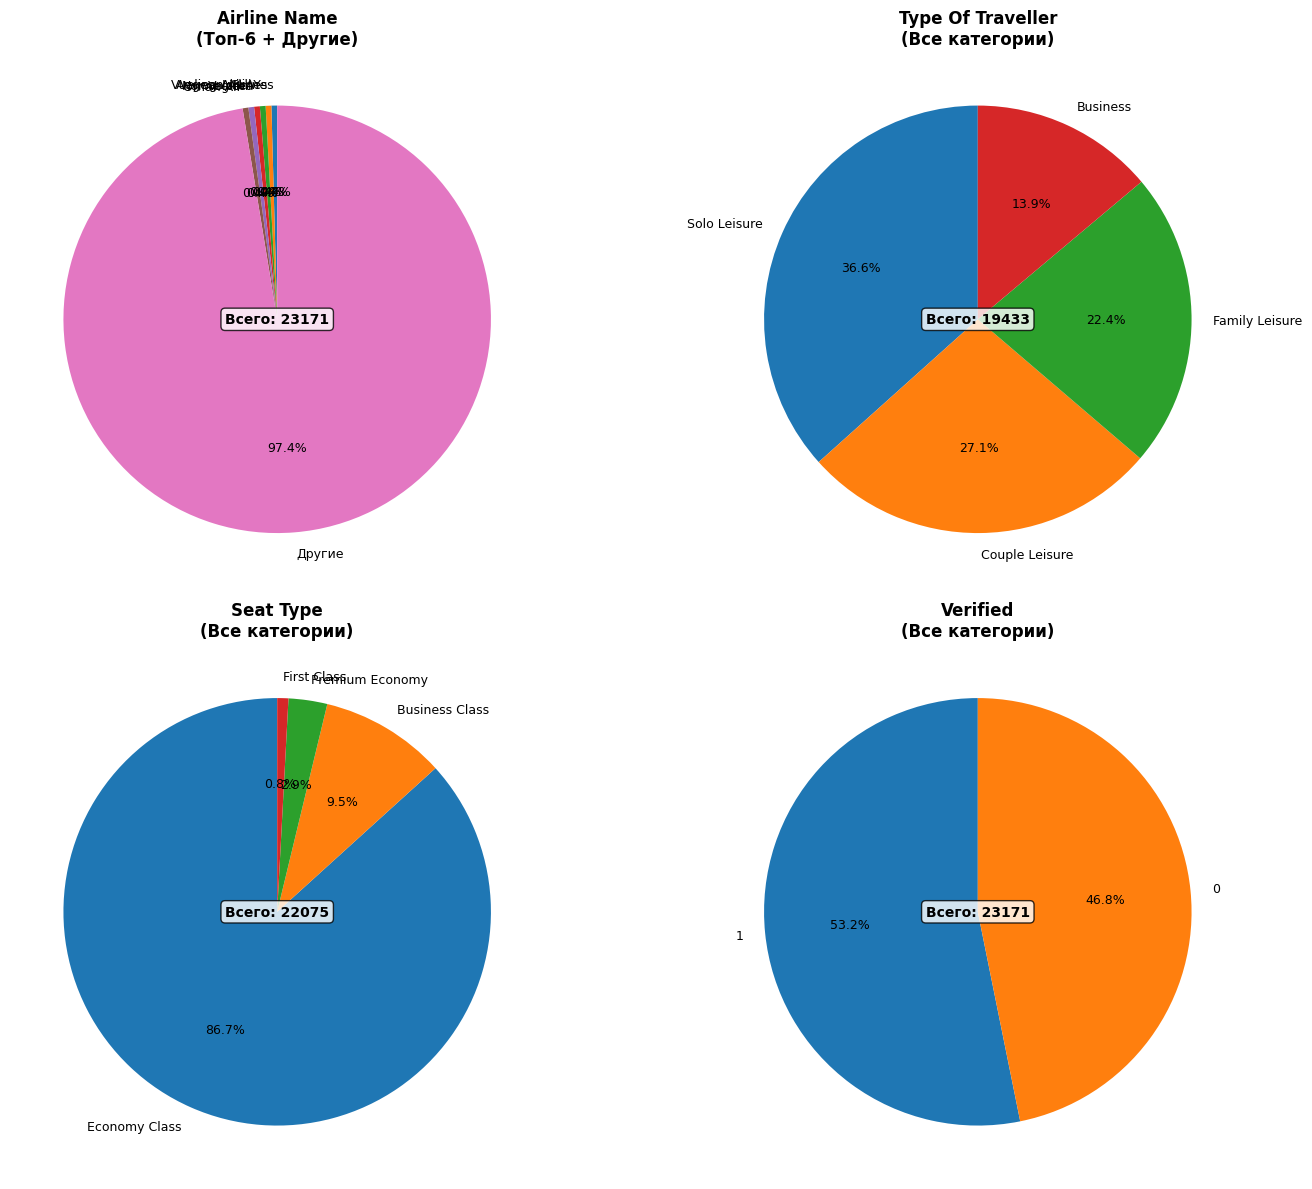

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_columns):
    # Определяем сколько категорий показывать в зависимости от признака
    unique_count = df[col].nunique()

    if unique_count <= 5:
        # Если категорий мало - показываем все
        top_values = df[col].value_counts()
        title_suffix = "Все категории"
    elif unique_count <= 10:
        # Если категорий до 10 - показываем топ-8
        top_values = df[col].value_counts().head(8)
        title_suffix = "Топ-8"
    else:
        # Если категорий много - показываем топ-6, остальные объединяем в "Другие"
        top_6 = df[col].value_counts().head(6)
        other_count = df[col].value_counts().iloc[6:].sum()
        top_values = pd.concat([top_6, pd.Series([other_count], index=['Другие'])])
        title_suffix = "Топ-6 + Другие"

    # Круговая диаграмма
    axes[i].pie(top_values.values, labels=top_values.index, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 9})
    axes[i].set_title(f'{col}\n({title_suffix})', fontsize=12, fontweight='bold')

    # Добавляем общее количество
    total = len(df[col].dropna())
    axes[i].text(0, 0, f'Всего: {total}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

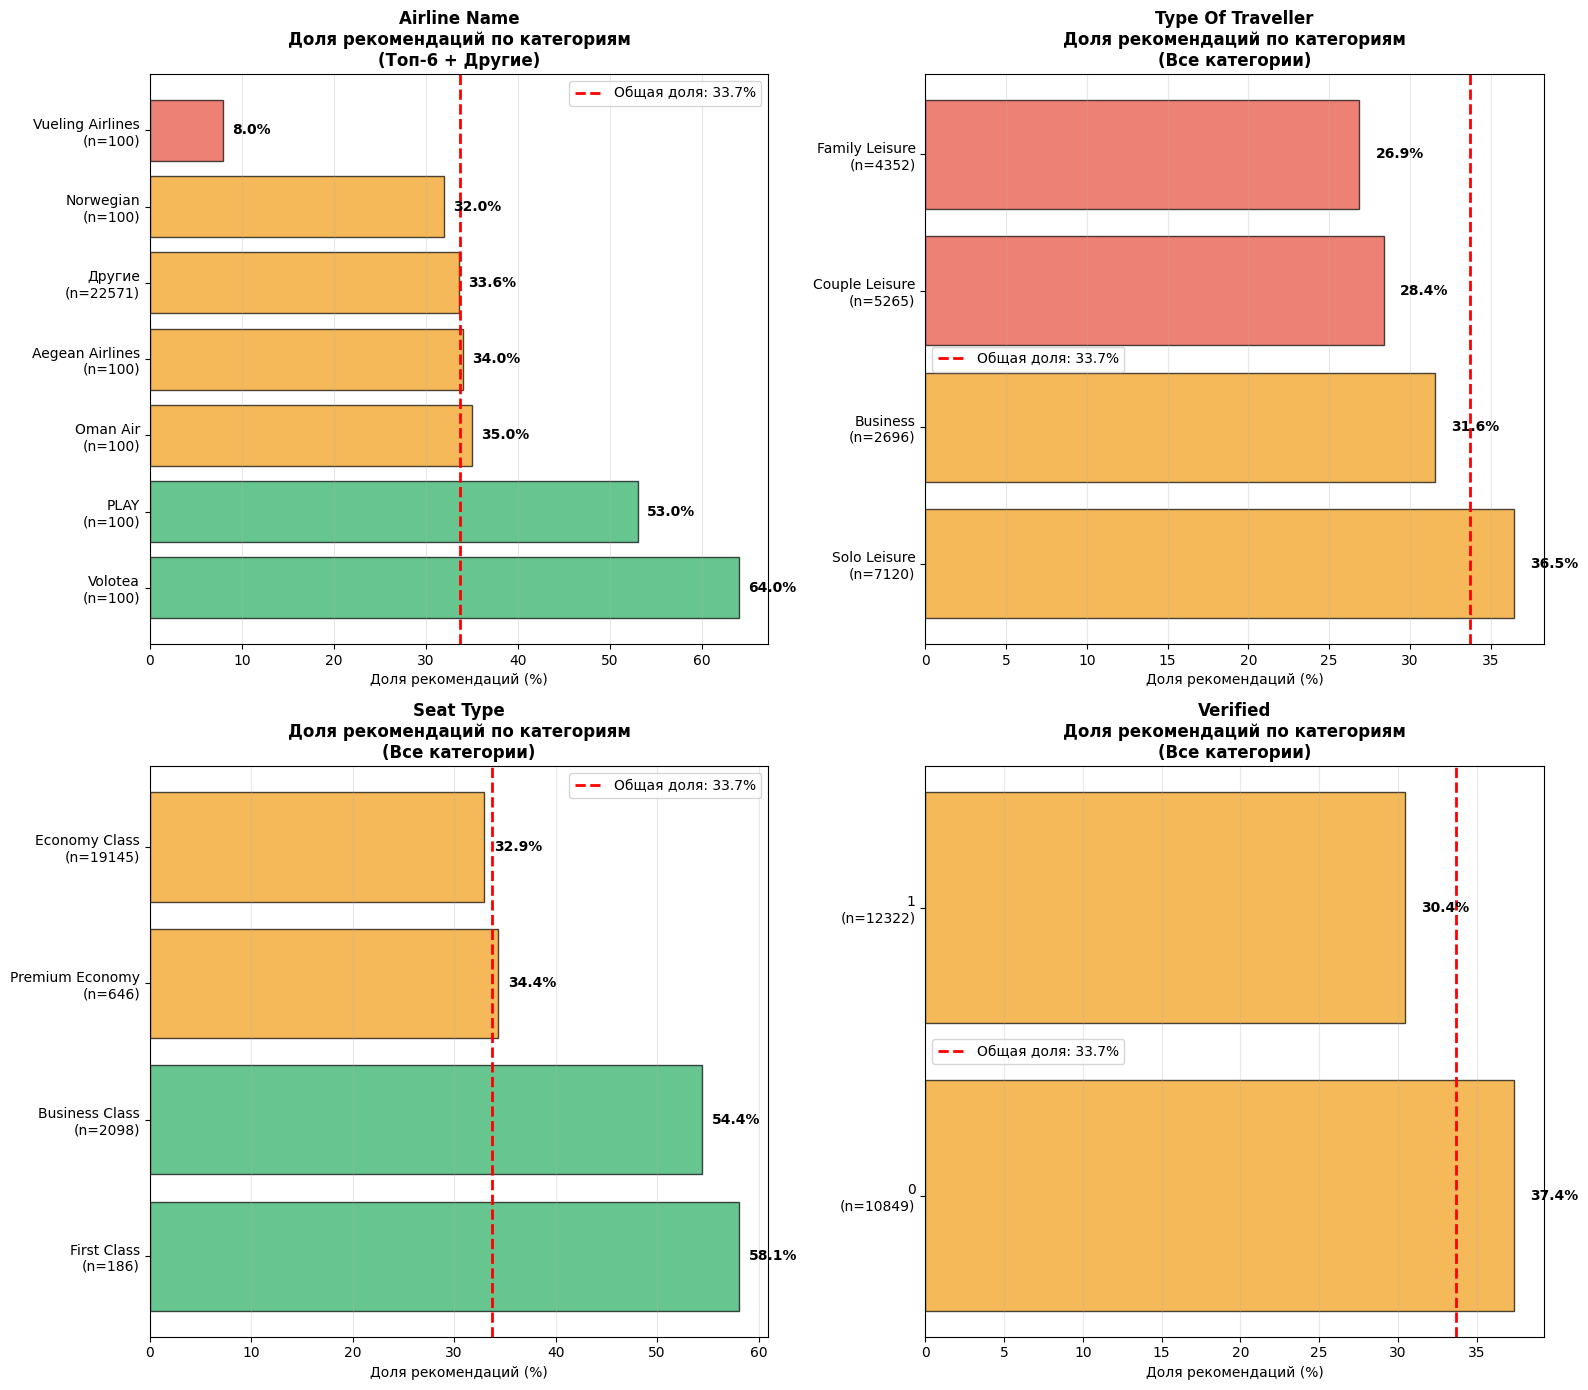

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for i, col in enumerate(categorical_columns):
    # Определяем категории для отображения (такие же как в круговой диаграмме)
    unique_count = df[col].nunique()

    if unique_count <= 5:
        categories = df[col].value_counts().index
        title_suffix = "Все категории"
    elif unique_count <= 10:
        categories = df[col].value_counts().head(8).index
        title_suffix = "Топ-8"
    else:
        categories = df[col].value_counts().head(6).index
        title_suffix = "Топ-6"

    # Собираем данные о доле рекомендаций
    category_names = []
    rec_rates = []
    counts = []

    for category in categories:
        mask = df[col] == category
        count = mask.sum()
        if count > 0:
            rec_rate = df.loc[mask, 'recom'].mean() * 100
            category_names.append(category)
            rec_rates.append(rec_rate)
            counts.append(count)

    # Добавляем "Другие" если нужно
    if unique_count > 10 and len(categories) == 6:
        other_mask = ~df[col].isin(categories) & df[col].notna()
        other_count = other_mask.sum()
        if other_count > 0:
            other_rec_rate = df.loc[other_mask, 'recom'].mean() * 100
            category_names.append("Другие")
            rec_rates.append(other_rec_rate)
            counts.append(other_count)
            title_suffix = "Топ-6 + Другие"

    # Сортируем по доле рекомендаций
    sorted_data = sorted(zip(category_names, rec_rates, counts), key=lambda x: x[1], reverse=True)
    category_names, rec_rates, counts = zip(*sorted_data)

    # Столбчатая диаграмма с долями рекомендаций
    bars = axes[i].barh(range(len(category_names)), rec_rates,
                       color=['#2ecc71' if rate >= 70 else
                              '#27ae60' if rate >= 50 else
                              '#f39c12' if rate >= 30 else
                              '#e74c3c' for rate in rec_rates],
                       alpha=0.7, edgecolor='black')

    axes[i].set_title(f'{col}\nДоля рекомендаций по категориям\n({title_suffix})',
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Доля рекомендаций (%)')
    axes[i].set_yticks(range(len(category_names)))
    axes[i].set_yticklabels([f"{name}\n(n={count})" for name, count in zip(category_names, counts)])
    axes[i].grid(axis='x', alpha=0.3)

    # Добавляем значения на столбцы
    for j, (rate, count) in enumerate(zip(rec_rates, counts)):
        axes[i].text(rate + 1, j, f'{rate:.1f}%', va='center', fontweight='bold')

    # Линия общей доли рекомендаций
    overall_rate = df['recom'].mean() * 100
    axes[i].axvline(x=overall_rate, color='red', linestyle='--', linewidth=2,
                   label=f'Общая доля: {overall_rate:.1f}%')
    axes[i].legend()

plt.tight_layout()
plt.show()

Более часто рекомендуют авиакомпанию пассажиры первого и бизнес класса

In [141]:
#Кодируем категориальные признаки
# Создаем копию данных для обработки
df_encoded = df.copy()
label_encoders_all = {}

for col in categorical_columns:
    print(f"Кодируем {col}...")

    # Создаем кодировщик
    le = LabelEncoder()

    # Кодируем на всех данных
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    label_encoders_all[col] = le
    print(f"  Уникальных значений: {len(le.classes_)}")


Кодируем Airline Name...
  Уникальных значений: 497
Кодируем Type Of Traveller...
  Уникальных значений: 5
Кодируем Seat Type...
  Уникальных значений: 5
Кодируем Verified...
  Уникальных значений: 2


In [142]:
#Разделение на тестовую и трейн выборки

# Создаем X и y из закодированных данных
X_encoded = df_encoded[numeric_columns + categorical_columns]
y_encoded = df_encoded['recom']

print(f"Размер данных для разделения: {X_encoded.shape}")

# Разделяем на train/test
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Обучающая выборка: {X_train_enc.shape[0]} строк")
print(f"Тестовая выборка: {X_test_enc.shape[0]} строк")
print(f"Доля рекомендаций: {y_train_enc.mean():.1%}")

Размер данных для разделения: (23171, 12)
Обучающая выборка: 16219 строк
Тестовая выборка: 6952 строк
Доля рекомендаций: 33.7%


In [143]:
#Заполнение пропусков

# Разделяем данные на числовые и категориальные
X_train_num = X_train_enc[numeric_columns].copy()
X_train_cat = X_train_enc[categorical_columns].copy()

X_test_num = X_test_enc[numeric_columns].copy()
X_test_cat = X_test_enc[categorical_columns].copy()

# Для числовых признаков используем медиану
num_imputer = SimpleImputer(strategy='median')
X_train_num_filled = num_imputer.fit_transform(X_train_num)
X_test_num_filled = num_imputer.transform(X_test_num)

# Для категориальных признаков используем моду
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat_filled = cat_imputer.fit_transform(X_train_cat)
X_test_cat_filled = cat_imputer.transform(X_test_cat)



In [144]:


# Собираем данные обратно
X_train_processed = pd.DataFrame(
    np.column_stack([X_train_num_filled, X_train_cat_filled]),
    columns=numeric_columns + categorical_columns,
    index=X_train_enc.index
)

X_test_processed = pd.DataFrame(
    np.column_stack([X_test_num_filled, X_test_cat_filled]),
    columns=numeric_columns + categorical_columns,
    index=X_test_enc.index
)

print(f"Проверка - пропуски в обучающей: {X_train_processed.isnull().sum().sum()}")
print(f"Проверка - пропуски в тестовой: {X_test_processed.isnull().sum().sum()}")

Проверка - пропуски в обучающей: 0
Проверка - пропуски в тестовой: 0


In [145]:
# Нормализуем данные
scaler_enc = StandardScaler()
X_train_scaled_enc = scaler_enc.fit_transform(X_train_processed)
X_test_scaled_enc = scaler_enc.transform(X_test_processed)

# Обучаем модель
knn_enc = KNeighborsClassifier(n_neighbors=5)
knn_enc.fit(X_train_scaled_enc, y_train_enc)

# Предсказания
y_pred_enc = knn_enc.predict(X_test_scaled_enc)


print(f"accuracy на тесте: {accuracy_score(y_test_enc, y_pred_enc):.3f}")

accuracy на тесте: 0.957


Отчет классификации:
                precision    recall  f1-score   support

Не рекомендуют       0.97      0.97      0.97      4610
   Рекомендуют       0.93      0.94      0.94      2342

      accuracy                           0.96      6952
     macro avg       0.95      0.95      0.95      6952
  weighted avg       0.96      0.96      0.96      6952



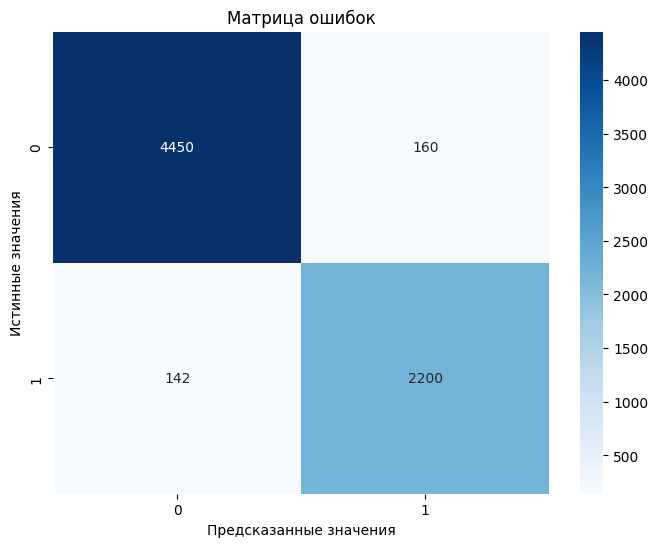

In [146]:
print("Отчет классификации:")
print(classification_report(y_test_enc, y_pred_enc, target_names=['Не рекомендуют', 'Рекомендуют']))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_enc, y_pred_enc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

KNN с k=5 


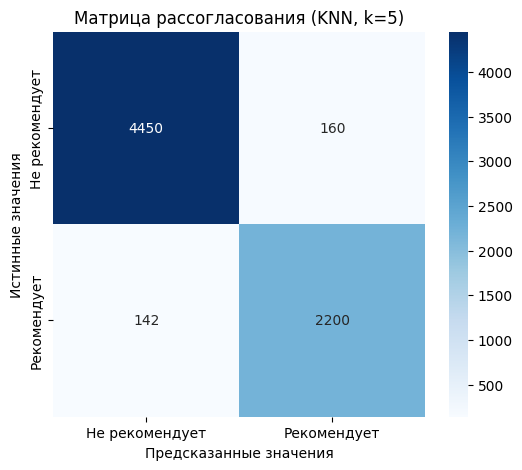

                precision    recall  f1-score   support

Не рекомендует       0.97      0.97      0.97      4610
   Рекомендует       0.93      0.94      0.94      2342

      accuracy                           0.96      6952
     macro avg       0.95      0.95      0.95      6952
  weighted avg       0.96      0.96      0.96      6952


ПОДБОР ОПТИМАЛЬНОГО K:


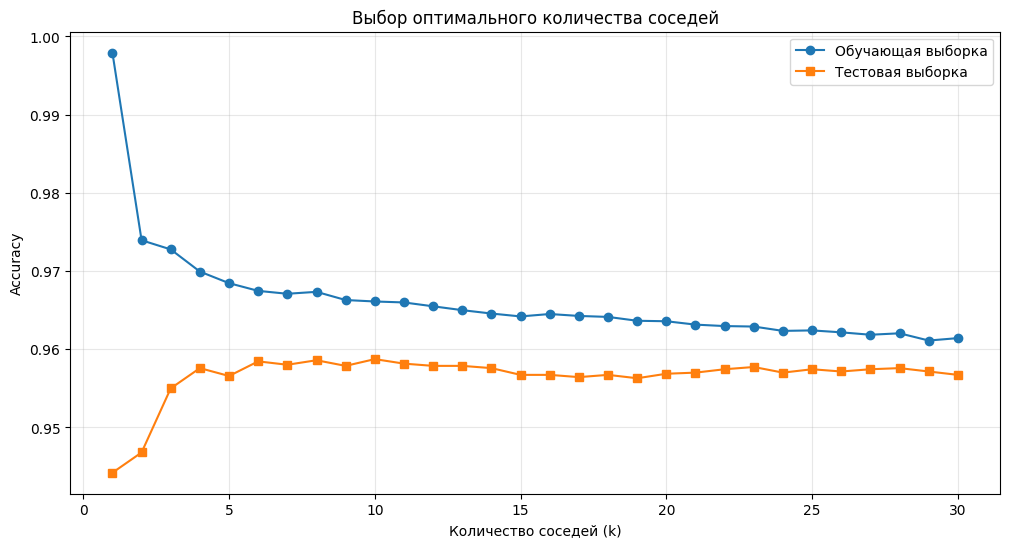

Оптимальное k: 10
Лучшая accuracy на тесте: 0.959

 ФИНАЛЬНАЯ МОДЕЛЬ (k=10)
Accuracy: 0.959


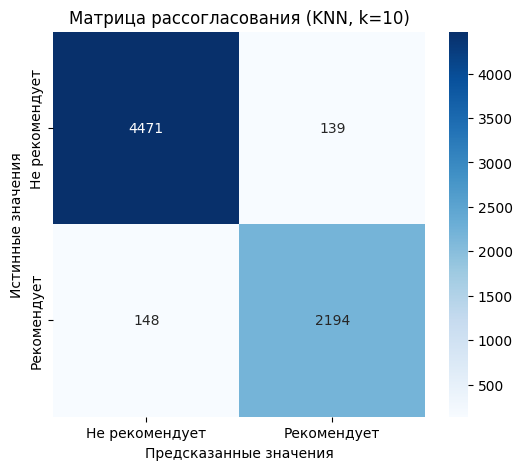

                precision    recall  f1-score   support

Не рекомендует       0.97      0.97      0.97      4610
   Рекомендует       0.94      0.94      0.94      2342

      accuracy                           0.96      6952
     macro avg       0.95      0.95      0.95      6952
  weighted avg       0.96      0.96      0.96      6952



In [147]:
#Выбор k

# Функция для матрицы рассогласования
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не рекомендует', 'Рекомендует'],
                yticklabels=['Не рекомендует', 'Рекомендует'])
    plt.title(title)
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.show()

# Оценка базовой модели
print("KNN с k=5 ")
plot_confusion_matrix(y_test_enc, y_pred_enc, 'Матрица рассогласования (KNN, k=5)')
print(classification_report(y_test_enc, y_pred_enc, target_names=['Не рекомендует', 'Рекомендует']))

# Подбор оптимального k
print("\nПОДБОР ОПТИМАЛЬНОГО K:")
train_scores = []
test_scores = []
k_values = range(1, 31)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled_enc, y_train_enc)
    train_scores.append(accuracy_score(y_train_enc, knn_temp.predict(X_train_scaled_enc)))
    test_scores.append(accuracy_score(y_test_enc, knn_temp.predict(X_test_scaled_enc)))

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, label='Обучающая выборка', marker='o')
plt.plot(k_values, test_scores, label='Тестовая выборка', marker='s')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.title('Выбор оптимального количества соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Находим оптимальное k
optimal_k = k_values[np.argmax(test_scores)]
best_score = max(test_scores)

print(f"Оптимальное k: {optimal_k}")
print(f"Лучшая accuracy на тесте: {best_score:.3f}")

# Финальная модель
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled_enc, y_train_enc)
y_test_final = final_knn.predict(X_test_scaled_enc)

print(f"\n ФИНАЛЬНАЯ МОДЕЛЬ (k={optimal_k})")
print(f"Accuracy: {accuracy_score(y_test_enc, y_test_final):.3f}")
plot_confusion_matrix(y_test_enc, y_test_final, f'Матрица рассогласования (KNN, k={optimal_k})')
print(classification_report(y_test_enc, y_test_final, target_names=['Не рекомендует', 'Рекомендует']))

Выводы: метод ближайших соседей достаточно хорошо справляется с этой задачей бинарной классификации, возможно для улучшения можно использовать текстовые признаки(+ как-то кластеризовать авиакомпании)